# Predicción de Calidad de Agua - Sudáfrica

Comparación entre **Random Forest** y **XGBoost** para predecir 3 parámetros de calidad del agua usando datos satelitales.

---

## PASO 1: Instalar librerías

In [1]:
!pip install xgboost -q

## PASO 2: Importar librerías

In [2]:
# Manejo de datos y gráficas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-darkgrid')

## PASO 3: Subir el dataset desde computadora

In [3]:
# Abre una ventana para subir el archivo dataset_winsorizado.csv
from google.colab import files
uploaded = files.upload()

Saving dataset_winsorizado.csv to dataset_winsorizado.csv


## PASO 4: Cargar los datos en una tabla

In [4]:
# Lee el CSV y muestra las primeras filas
df = pd.read_csv('dataset_winsorizado.csv', index_col=0)
print(f'Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset: 9319 filas × 13 columnas


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,nir,green,swir16,swir22,NDMI,MNDWI
0,-28.760833,17.730278,2011-02-01,128.912,555.0,10.0,174.2,11190.0,11426.0,7687.5,7645.0,0.185538,0.012751
1,-26.861111,28.884722,2011-03-01,74.720,162.9,163.0,124.1,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,2011-03-01,89.254,573.0,80.0,127.5,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,2011-03-01,82.000,203.6,101.0,129.7,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,2011-03-01,56.100,145.1,151.0,129.2,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683


## PASO 5: Exploración rápida

In [5]:
# Estadísticas básicas y verificación de nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
df.describe().round(2)

Valores nulos por columna:
Latitude                         0
Longitude                        0
Sample Date                      0
Total Alkalinity                 0
Electrical Conductance           0
Dissolved Reactive Phosphorus    0
pet                              0
nir                              0
green                            0
swir16                           0
swir22                           0
NDMI                             0
MNDWI                            0
dtype: int64


,Latitude,Longitude,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,nir,green,swir16,swir22,NDMI,MNDWI
count,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00,9319.00
mean,-28.47,26.87,119.11,485.00,43.53,175.17,14061.50,9962.00,13583.39,11406.88,0.02,-0.15
std,2.76,3.54,74.69,341.94,50.98,29.47,2776.32,2612.65,3147.84,2395.80,0.07,0.08
min,-34.41,17.73,4.80,15.12,5.00,52.70,3992.00,4045.00,3672.50,3634.00,-0.33,-0.30
25%,-30.16,26.13,55.81,207.05,10.00,156.10,12983.25,9441.50,12099.75,10049.50,-0.03,-0.21
50%,-28.06,27.41,113.30,402.00,20.00,172.50,14183.00,9801.00,13704.25,11265.25,0.02,-0.17
75%,-26.86,29.25,170.23,693.00,48.00,193.10,15293.00,10213.00,15172.50,12633.00,0.07,-0.12
max,-22.23,32.33,361.68,1506.00,195.00,270.80,65535.00,65535.00,65535.00,31202.50,0.57,0.01


## PASO 6: Separar features (X) y targets (y)

- **X** = lo que usamos para predecir (variables satelitales y de ubicación).
- **y** = lo que queremos predecir (3 parámetros de calidad del agua).

In [6]:
# Definimos qué columnas son entrada (X) y cuáles salida (y)
features = ['pet', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'Latitude', 'Longitude']
targets  = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

X = df[features].copy()
y = df[targets].copy()

print(f'X: {X.shape}  |  y: {y.shape}')

X: (9319, 9)  |  y: (9319, 3)


## PASO 7: Dividir en train (70%) y test (30%)

El modelo aprende con `train` y se evalúa con `test` (datos que nunca vio).

In [7]:
# Split 70/30 con random_state=42 para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas')

Train: 6523 filas  |  Test: 2796 filas


## PASO 8: Escalar los datos

Pone todas las variables en la misma escala (media 0, desviación 1) para que el modelo no se confunda con números muy diferentes.

In [8]:
# fit_transform en train (aprende y transforma), transform en test (solo transforma)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Datos escalados ✅')

Datos escalados ✅


---
## MODELO 1: Random Forest

Crea 100 árboles de decisión y promedia sus predicciones. Es como preguntarle a 100 expertos y juntar sus respuestas.

In [9]:
# Entrenamos un Random Forest por cada target y guardamos resultados
modelos_rf = {}
resultados_rf = {}

for target in targets:
    modelo = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    modelo.fit(X_train_scaled, y_train[target])
    pred = modelo.predict(X_test_scaled)

    modelos_rf[target] = modelo
    resultados_rf[target] = {
        'R2': r2_score(y_test[target], pred),
        'MAE': mean_absolute_error(y_test[target], pred),
        'RMSE': np.sqrt(mean_squared_error(y_test[target], pred)),
        'pred': pred
    }
    print(f'{target}: R²={resultados_rf[target]["R2"]:.4f}  RMSE={resultados_rf[target]["RMSE"]:.2f}')

Total Alkalinity: R²=0.8164  RMSE=32.33
Electrical Conductance: R²=0.8496  RMSE=132.53
Dissolved Reactive Phosphorus: R²=0.6746  RMSE=29.25


---
## MODELO 2: XGBoost

Entrena 100 árboles en secuencia, donde cada uno corrige los errores del anterior. Generalmente da mejores resultados que Random Forest.

In [10]:
# Entrenamos un XGBoost por cada target y guardamos resultados
modelos_xgb = {}
resultados_xgb = {}

for target in targets:
    modelo = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
    modelo.fit(X_train_scaled, y_train[target])
    pred = modelo.predict(X_test_scaled)

    modelos_xgb[target] = modelo
    resultados_xgb[target] = {
        'R2': r2_score(y_test[target], pred),
        'MAE': mean_absolute_error(y_test[target], pred),
        'RMSE': np.sqrt(mean_squared_error(y_test[target], pred)),
        'pred': pred
    }
    print(f'{target}: R²={resultados_xgb[target]["R2"]:.4f}  RMSE={resultados_xgb[target]["RMSE"]:.2f}')

Total Alkalinity: R²=0.7839  RMSE=35.08
Electrical Conductance: R²=0.8076  RMSE=149.87
Dissolved Reactive Phosphorus: R²=0.6213  RMSE=31.55


---
## abla comparativa: Random Forest vs XGBoost

In [11]:
# Tabla con R², MAE y diferencia entre ambos modelos
comparacion = pd.DataFrame({
    'Target': targets,
    'R² Random Forest': [resultados_rf[t]['R2']  for t in targets],
    'R² XGBoost':       [resultados_xgb[t]['R2'] for t in targets],
    'MAE Random Forest': [resultados_rf[t]['MAE']  for t in targets],
    'MAE XGBoost':       [resultados_xgb[t]['MAE'] for t in targets],
}).round(4)

comparacion['Mejora R² (%)'] = ((comparacion['R² XGBoost'] - comparacion['R² Random Forest']) * 100).round(2)
comparacion

,Target,R² Random Forest,R² XGBoost,MAE Random Forest,MAE XGBoost,Mejora R² (%)
0,Total Alkalinity,0.8164,0.7839,20.9242,24.7619,-3.25
1,Electrical Conductance,0.8496,0.8076,78.2856,99.3895,-4.20
2,Dissolved Reactive Phosphorus,0.6746,0.6213,17.1794,20.2823,-5.33


## Gráfica: R² de ambos modelos

La barra más alta gana en cada par.

/tmp/ipykernel_2605/416314130.py:25: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2605/416314130.py:25: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


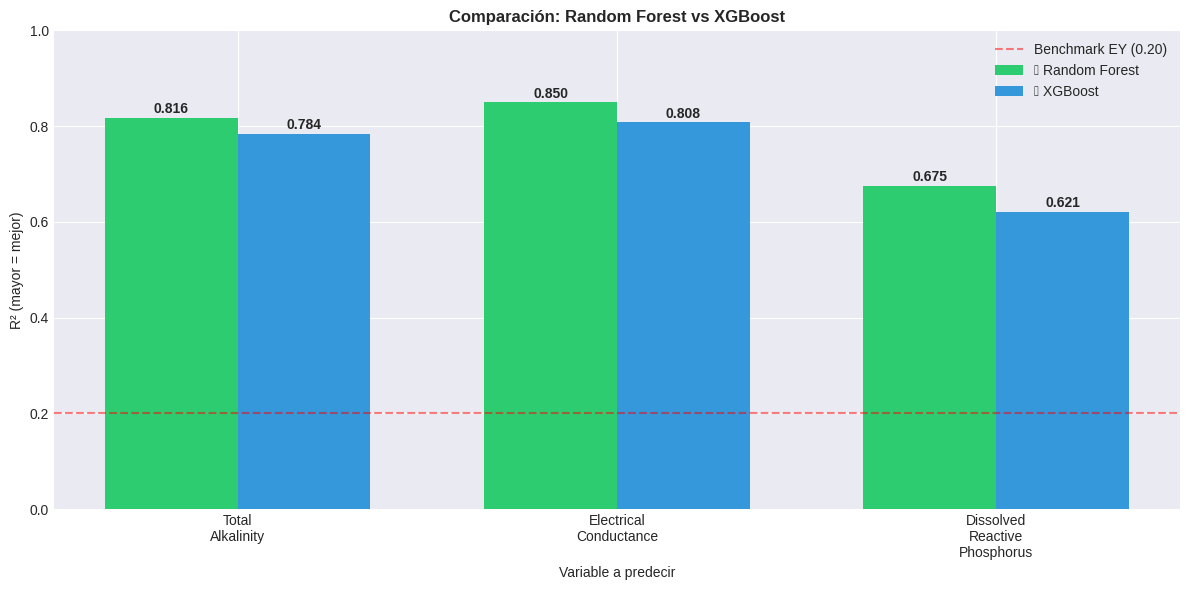

In [12]:
# Gráfica de barras comparando R² con línea del benchmark EY (0.20)
r2_rf  = [resultados_rf[t]['R2']  for t in targets]
r2_xgb = [resultados_xgb[t]['R2'] for t in targets]
x = np.arange(len(targets))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
barras_rf  = ax.bar(x - ancho/2, r2_rf,  ancho, label='🌲 Random Forest', color='#2ecc71')
barras_xgb = ax.bar(x + ancho/2, r2_xgb, ancho, label='⚡ XGBoost',       color='#3498db')

ax.set_xlabel('Variable a predecir')
ax.set_ylabel('R² (mayor = mejor)')
ax.set_title('Comparación: Random Forest vs XGBoost', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([t.replace(' ', '\n') for t in targets])
ax.axhline(y=0.20, color='red', linestyle='--', alpha=0.5, label='Benchmark EY (0.20)')
ax.legend()
ax.set_ylim(0, 1)

for barras in [barras_rf, barras_xgb]:
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, altura + 0.01, f'{altura:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Gráfica: Predicción vs Realidad

Cada punto es una predicción. La línea roja diagonal es la predicción perfecta. **Mientras más cerca de la línea, mejor.**

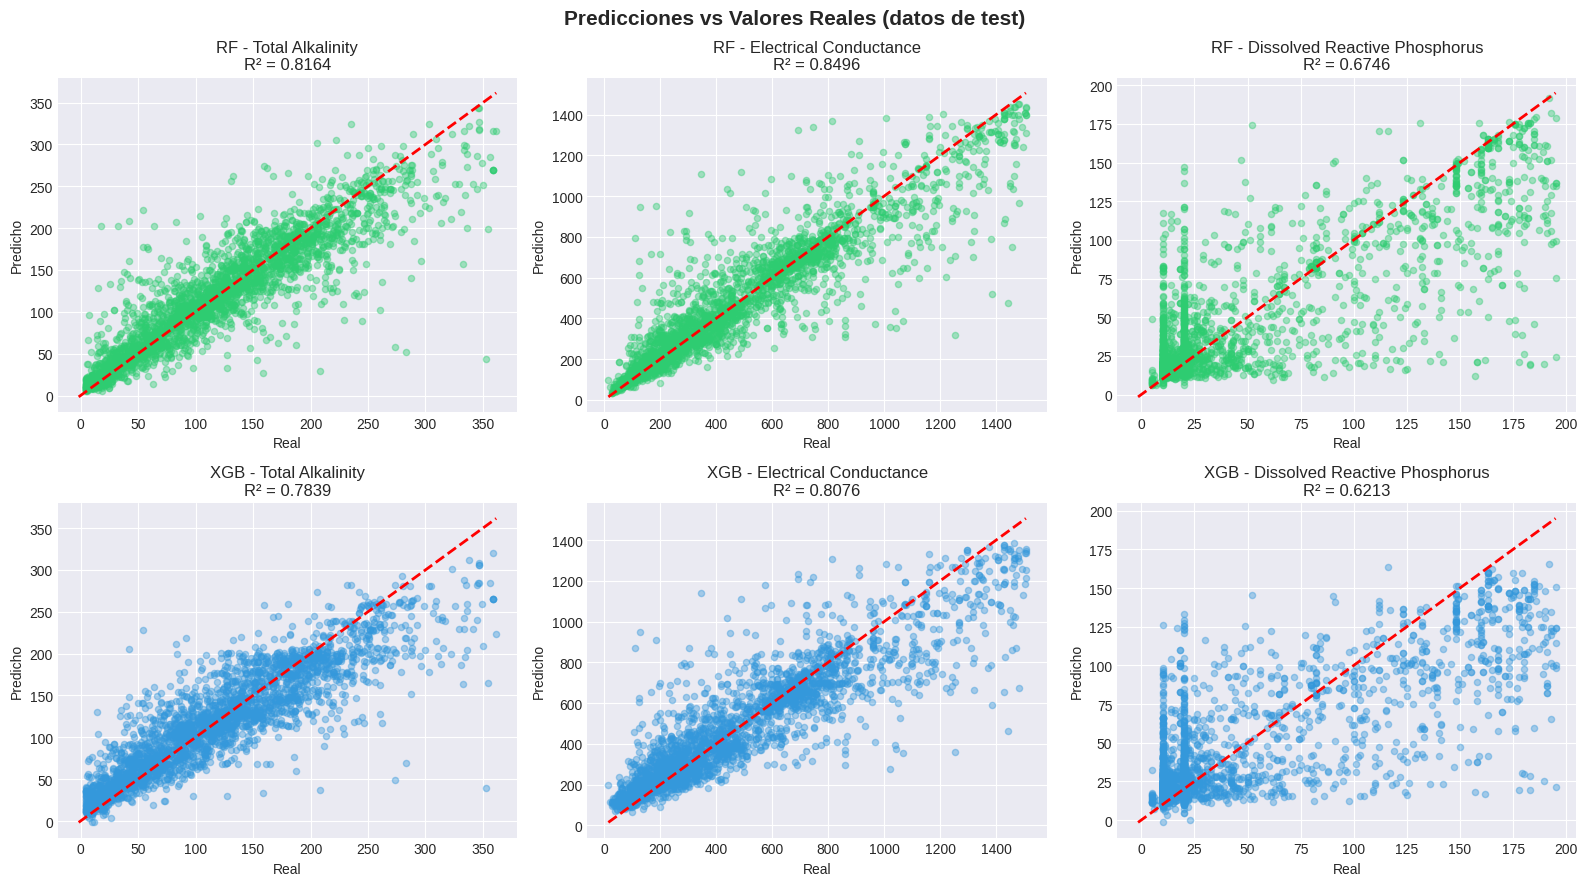

In [15]:
# Scatter plots de predicho vs real para los 3 targets en ambos modelos
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Predicciones vs Valores Reales (datos de test)', fontsize=15, fontweight='bold')

for col, target in enumerate(targets):
    y_real = y_test[target].values
    min_val = min(y_real.min(), resultados_rf[target]['pred'].min(), resultados_xgb[target]['pred'].min())
    max_val = max(y_real.max(), resultados_rf[target]['pred'].max(), resultados_xgb[target]['pred'].max())

    ax = axes[0, col]
    ax.scatter(y_real, resultados_rf[target]['pred'], alpha=0.4, s=20, color='#2ecc71')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_title(f'RF - {target}\nR² = {resultados_rf[target]["R2"]:.4f}')
    ax.set_xlabel('Real'); ax.set_ylabel('Predicho')

    ax = axes[1, col]
    ax.scatter(y_real, resultados_xgb[target]['pred'], alpha=0.4, s=20, color='#3498db')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_title(f'XGB - {target}\nR² = {resultados_xgb[target]["R2"]:.4f}')
    ax.set_xlabel('Real'); ax.set_ylabel('Predicho')

plt.tight_layout()
plt.show()

## Importancia de variables (XGBoost)

Las barras más largas son las variables que más ayudaron al modelo a predecir.

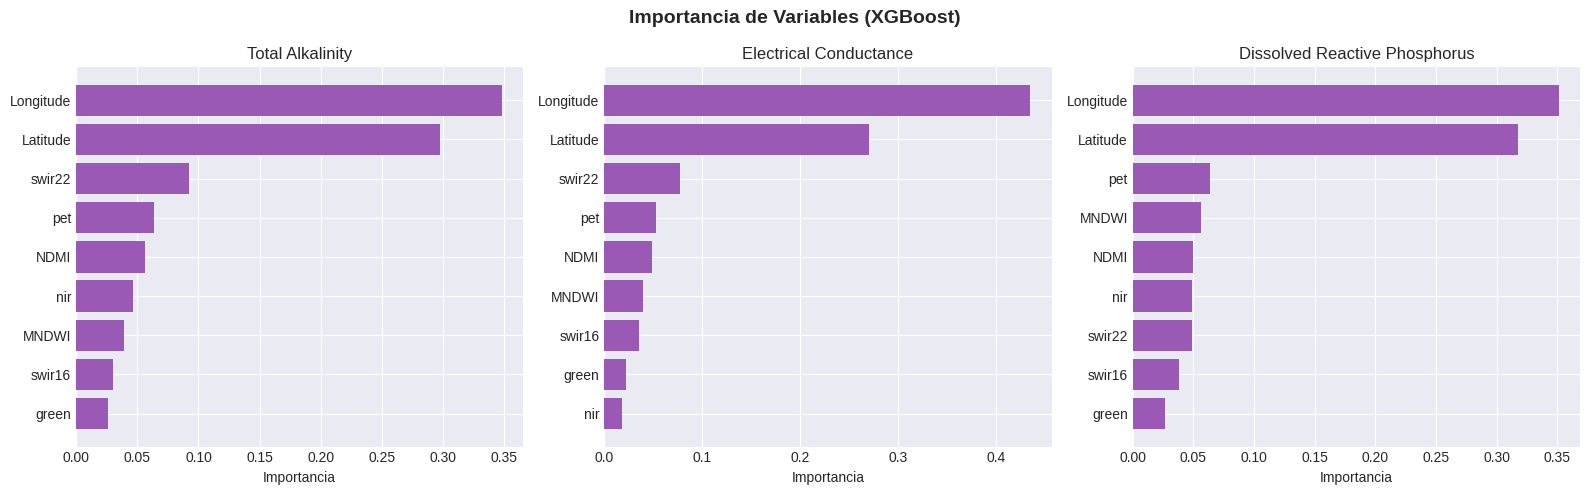

In [16]:
# Importancia de cada feature según XGBoost, una gráfica por target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Importancia de Variables (XGBoost)', fontsize=14, fontweight='bold')

for col, target in enumerate(targets):
    importancias = modelos_xgb[target].feature_importances_
    indices = np.argsort(importancias)
    axes[col].barh([features[i] for i in indices], importancias[indices], color='#9b59b6')
    axes[col].set_title(target)
    axes[col].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

---
## RESULTADOS GENERALES

In [17]:
# Decidimos el modelo ganador basado en R² promedio
r2_promedio_rf  = np.mean([resultados_rf[t]['R2']  for t in targets])
r2_promedio_xgb = np.mean([resultados_xgb[t]['R2'] for t in targets])

if r2_promedio_xgb > r2_promedio_rf:
    ganador = 'XGBoost'
    ventaja = (r2_promedio_xgb - r2_promedio_rf) * 100
else:
    ganador = 'Random Forest'
    ventaja = (r2_promedio_rf - r2_promedio_xgb) * 100

print('=' * 60)
print('RESULTADOS GENERALES')
print('=' * 60)
print(f'\nR² PROMEDIO:')
print(f'   Random Forest: {r2_promedio_rf:.4f}')
print(f'   XGBoost:       {r2_promedio_xgb:.4f}')
print(f'\nGANADOR: {ganador}  (ventaja de {ventaja:.2f}% en R² promedio)')

print(f'\nRESULTADO POR PARÁMETRO:')
for target in targets:
    rf  = resultados_rf[target]['R2']
    xgb = resultados_xgb[target]['R2']
    mejor = 'XGBoost' if xgb > rf else 'Random Forest'
    print(f'   • {target}:  RF={rf:.4f}  |  XGB={xgb:.4f}  → {mejor}')

print(f'\n🎯 vs BENCHMARK EY (R² = 0.20):')
for target in targets:
    xgb = resultados_xgb[target]['R2']
    estado = 'SUPERA' if xgb > 0.20 else 'NO supera'
    print(f'   • {target}: {estado} (R²={xgb:.4f})')

print('\n' + '=' * 60)
print(f'CONCLUSIÓN: el modelo recomendado para el proyecto es {ganador}')
print('=' * 60)

RESULTADOS GENERALES

R² PROMEDIO:
   Random Forest: 0.7802
   XGBoost:       0.7376

GANADOR: Random Forest  (ventaja de 4.26% en R² promedio)

RESULTADO POR PARÁMETRO:
   • Total Alkalinity:  RF=0.8164  |  XGB=0.7839  → Random Forest
   • Electrical Conductance:  RF=0.8496  |  XGB=0.8076  → Random Forest
   • Dissolved Reactive Phosphorus:  RF=0.6746  |  XGB=0.6213  → Random Forest

🎯 vs BENCHMARK EY (R² = 0.20):
   • Total Alkalinity: SUPERA (R²=0.7839)
   • Electrical Conductance: SUPERA (R²=0.8076)
   • Dissolved Reactive Phosphorus: SUPERA (R²=0.6213)

CONCLUSIÓN: el modelo recomendado para el proyecto es Random Forest
